In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

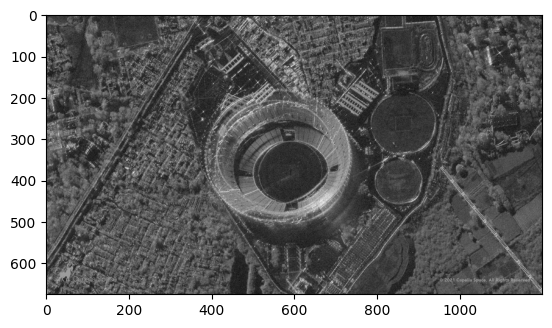

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")

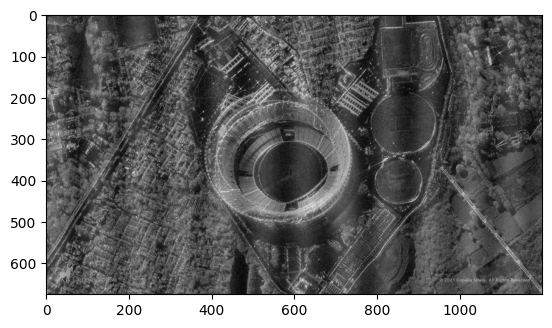

In [3]:
def per_ns(image, A=30, B=20, angle=0):
    h, w = image.shape[:2]

    y_coords, x_coords = np.mgrid[0:h, 0:w]

    theta = np.radians(angle)
    x_rot = x_coords * np.cos(theta) + y_coords * np.sin(theta)

    noise = np.sin(x_rot / B * 2 * np.pi) * A

    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

dist = per_ns(image_gray, A=20, B=100, angle=0)

plt.imshow(dist, cmap="gray")

In [4]:
image = dist.copy()

radius = 20

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

f = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)
fshift = np.fft.fftshift(f)

# band = True
# WIDTH = 10
# if band:
#     mask = np.ones((rows, cols, 2), np.uint8)
#     cv2.circle(mask, (ccol, crow), radius, color=0, thickness=WIDTH)
# else:
#     mask = np.zeros((rows, cols, 2), np.uint8)
#     mask[crow - radius : crow + radius, ccol - radius : ccol + radius, :] = 1

u = np.linspace(0, cols - 1, cols)
v = np.linspace(0, rows - 1, rows)
U, V = np.meshgrid(u - ccol, v - crow)

X = np.sqrt(U**2 + V**2)

n = 4
D = radius
mask_ = 1 / (1 + (X / D) ** (2 * n))

mask = np.zeros((rows, cols, 2), np.float32)
mask[:, :, 0] = mask_
mask[:, :, 1] = mask_

fshift_filtered = fshift * mask

f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

result = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

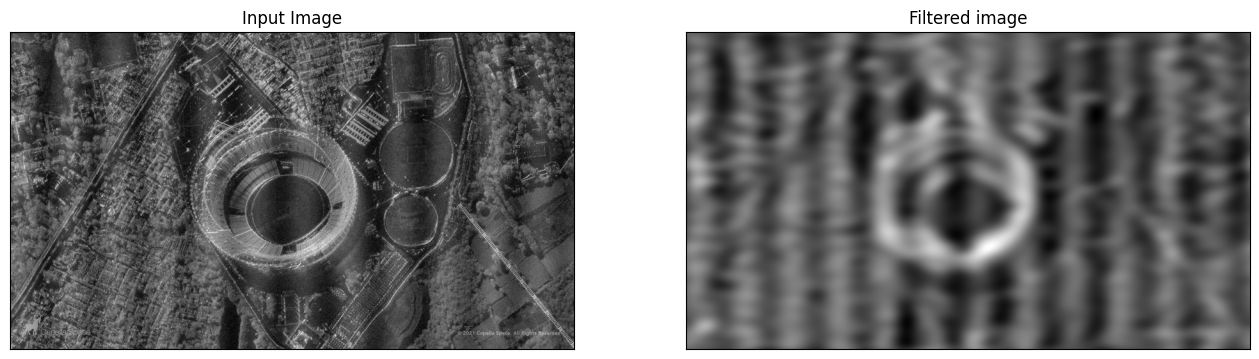

In [5]:
plt.figure(figsize=(16, 8))
plt.subplot(121), plt.imshow(dist, cmap="gray")
plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_back, cmap="gray")
plt.title("Filtered image"), plt.xticks([]), plt.yticks([])
plt.show()